# **PRAKTIKUM PERTEMUAN 5 DATA SCIENCE**

Nama : Bintang Hanifatul Manunggal

Nim :  250401020095

Kelas : IF405

In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:
# 1. LOAD DATASET
df = sns.load_dataset('tips')

print(df.shape)
print(df.dtypes)
print(df.describe().round(2))

(244, 7)
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_1114/3996013182.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


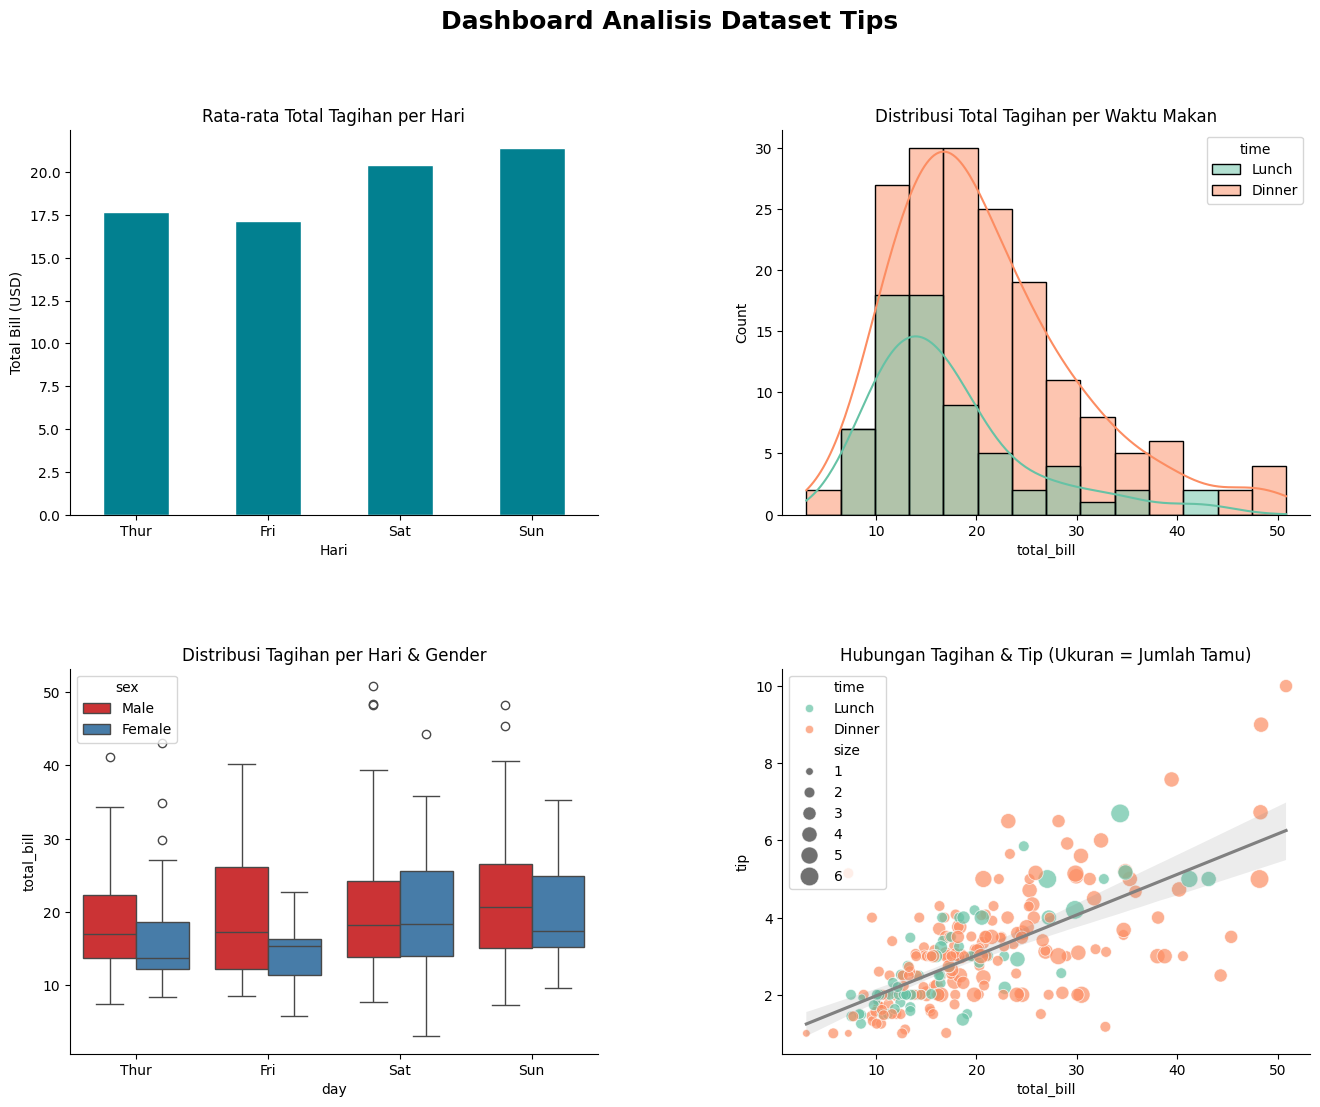

In [ ]:
# 2. SETUP FIGURE
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Dashboard Analisis Dataset Tips',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 3. Grafik 1
avg_by_day = df.groupby('day')['total_bill'].mean()

avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white'
)

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# 4. Grafik 2
sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# 5. Grafik 3
sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# 6. Grafik 4
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30,180),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)


In [ ]:
# 7. EKSPOR

plt.savefig(
    'dashboard_tips.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Dashboard tersimpan sebagai dashboard_tips.png')

<Figure size 640x480 with 0 Axes>

Dashboard tersimpan sebagai dashboard_tips.png


### **Analisis Grafik 1 - Bar Chart**

**1. What? (apa yang terlihat)**

Grafik menunjukkan rata-rata total tagihan pelanggan berdasarkan hari. Hari Minggu merupakan rata-rata tagihan tertinggi sekitar 21 USD, sedangkan Jumat merupakan rata-rata terendah sekitar 17 USD.

**2. So What? (mengapa penting)**

Hal ini menunjukkan jika pelanggan mengeluarkan lebih banyak uang pada weekend dibandingkan weekday. Informasi ini bisa membantu untuk memahami pola konsumsi pelanggan.

**3. Now What? (tindak lanjut atau pertanyaan eksplorasi)**

Analisis lebih lanjut bisa dilakukan untuk mengetahui apakah jumlah pelanggan pada weekend juga lebih tinggi sehingga memengaruhi rata-rata tagihan.

### **Analisis Grafik 2 - Histogram**

**1. What? (apa yang terlihat)**

Grafik menunjukkan sebagian besar transaksi mempunyai total tagihan antara 10 - 20 USD. Hanya sedikit transaksi yang memiliki nilai di atas 40 USD.

**2. So What? (mengapa penting)**

Distribusi ini menunjukkan bahwa mayoritas pelanggan memiliki pola pengeluaran yang relatif stabil pada rentang menengah.

**3. Now What? (tindak lanjut atau pertanyaan eksplorasi)**

Perlu dilakukan analisis terhadap transaksi bernilai tinggi untuk mengetahui karakteristik pelanggan yang melakukan pengeluaran lebih besar.

### **Analisis Grafik 3 - Boxplot**

**1. What? (apa yang terlihat)**

Grafik menunjukkan distribusi total tagihan berdasarkan hari dan gender pelanggan. Median total tagihan pada sebagian besar kelompok berada di kisaran 15 - 20 USD. Pada hari Minggu terdapat beberapa outlier dengan nilai tagihan mencapai lebih dari 45 USD, bahkan mendekati 50 USD.

**2. So What? (mengapa penting)**

Hal ini menunjukkan jika meskipun sebagian besar pelanggan memiliki pola pengeluaran yang mirip, terdapat sejumlah pelanggan yang melakukan transaksi jauh lebih besar dibandingkan rata-rata. adanya outlier dapat memengaruhi nilai rata-rata total tagihan.

**3. Now What? (tindak lanjut atau pertanyaan eksplorasi)**

Analisis lebih lanjut dapat dilakukan terhadap transaksi dengan nilai di atas 45 USD untuk mengetahui apakah dipengaruhi oleh jumlah tamu, waktu makan, atau faktor lainnya.

### **Analisis Grafik 4 - Scatter Plot**

**1. What? (apa yang terlihat)**

Grafik menunjukkan hubungan antara total tagihan dan jumlah tip. Sebagian besar transaksi berada pada rentang tagihan 10 - 30 USD dengan tip sekitar 2 - 5 USD. Sedangkan transaksi dengan total tagihan mendekati 50 USD rata rata memberikan tip sekitar 6 - 10 USD.

**2. So What? (mengapa penting)**

Pola ini menunjukkan jika semakin tinggi nilai tagihan, semakin besar pula tip yang diberikan pelanggan.

**3. Now What? (tindak lanjut atau pertanyaan eksplorasi)**

Langkah berikutnya yaitu menghitung nilai korelasi antara total tagihan dan tip untuk mengetahui seberapa kuat hubungan keduanya. Selain itu, dapat dianalisis apakah waktu makan (Lunch atau Dinner) memengaruhi besar tip yang diberikan.

### **Kesimpulan**

Pada praktikum pertemuan 5 ini, saya mempelajari cara membuat dashboard visualisasi data menggunakan Python dengan memanfaatkan library Pandas, Matplotlib, dan Seaborn. Dataset yang digunakan adalah dataset **Tips**, yang berisi informasi mengenai total tagihan, tip, jenis kelamin pelanggan, waktu makan, hari kunjungan, serta jumlah tamu.

Saya membuat dashboard yang terdiri dari beberapa jenis visualisasi, yaitu bar chart, histogram, boxplot, dan scatter plot. Melalui visualisasi tersebut, saya dapat mengamati berbagai pola dalam data, seperti rata-rata total tagihan berdasarkan hari, distribusi nilai tagihan pelanggan, perbandingan tagihan berdasarkan gender dan hari, serta hubungan antara total tagihan dengan jumlah tip yang diberikan.

Dari hasil analisis, saya menemukan bahwa rata-rata total tagihan cenderung lebih tinggi pada akhir pekan dibandingkan hari lainnya. Selain itu, sebagian besar transaksi berada pada rentang tagihan menengah, sementara transaksi dengan nilai sangat tinggi hanya terjadi pada beberapa kasus. Saya juga melihat adanya hubungan positif antara total tagihan dan jumlah tip, yang menunjukkan bahwa pelanggan dengan tagihan lebih besar cenderung memberikan tip yang lebih tinggi.

Melalui praktikum ini, saya memahami bahwa dashboard visualisasi dapat membantu menyajikan informasi yang kompleks menjadi lebih mudah dipahami. Saya juga belajar bagaimana menginterpretasikan hasil visualisasi menggunakan pendekatan **What, So What, dan Now What**, sehingga tidak hanya menampilkan grafik, tetapi juga mampu menarik insight dan menentukan langkah analisis berikutnya berdasarkan data yang tersedia.
